# Sampling & Monte Carlo

很多期望算不出来（积分没有闭式解），但可以**采样估计**。蒙特卡洛是深度学习一切随机性的底层引擎：mini-batch、Dropout、生成模型都靠它。


## 0. 环境配置与导入


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import torch
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


## 1. 为什么需要采样


期望 $\mathbb{E}[f(X)] = \int f(x)p(x)\,dx$ 常常不可解析计算。**蒙特卡洛估计**：

$$\frac{1}{n}\sum_{i=1}^n f(X_i) \xrightarrow{n\to\infty} \mathbb{E}[f(X)], \qquad X_i \sim p$$

误差 ~ $O(1/\sqrt{n})$（中心极限定理），与维度无关——高维积分唯一实用的方法。


## 2. 逆变换采样：F⁻¹(U)


若 $U \sim U(0,1)$，则 $X = F^{-1}(U)$ 服从分布 $F$（$F$ 是目标 CDF）。

**证明**：$P(X \le x) = P(F^{-1}(U) \le x) = P(U \le F(x)) = F(x)$ ✓

指数分布 $F(x) = 1 - e^{-\lambda x}$，所以 $X = -\ln(1-U)/\lambda$。


样本均值 = 1.2478（解析 1/λ = 1.2500）


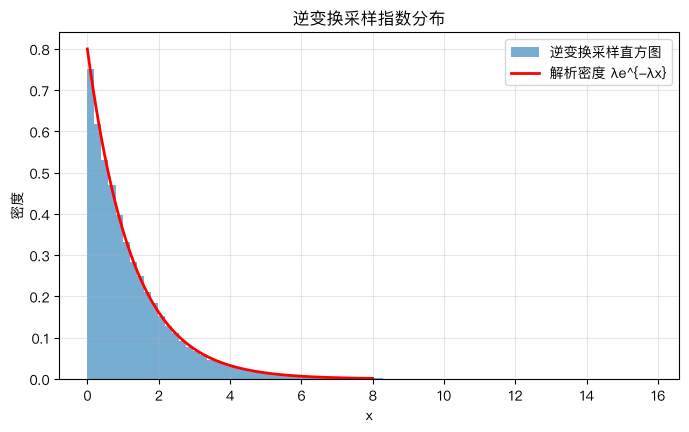

In [2]:
rng = np.random.default_rng(0)
lam = 0.8
U = rng.random(100000)
X = -np.log(1 - U) / lam

xs = np.linspace(0, 8, 200)
plt.figure(figsize=(8, 4.5))
plt.hist(X, bins=80, density=True, alpha=0.6, label='逆变换采样直方图')
plt.plot(xs, lam*np.exp(-lam*xs), 'r-', lw=2, label='解析密度 λe^{-λx}')
plt.xlabel('x'); plt.ylabel('密度')
plt.title('逆变换采样指数分布')
plt.legend(); plt.grid(alpha=0.3)
print(f"样本均值 = {X.mean():.4f}（解析 1/λ = {1/lam:.4f}）")


## 3. 拒绝采样：从"包装分布"里筛


目标 $p(x)$ 难采样，但能找到 $p(x) \le M\,q(x)$ 的易采样分布 $q$：

1. 采 $X \sim q$，采 $U \sim U(0,1)$
2. 若 $U < p(X)/(M q(X))$ 接受，否则拒绝

接受率 $= 1/M$。$M$ 越接近 $\max p/q$，效率越高。


实际接受率 = 0.626（理论 1/M = 0.625）
样本均值 = 0.5004（解析 0.5）


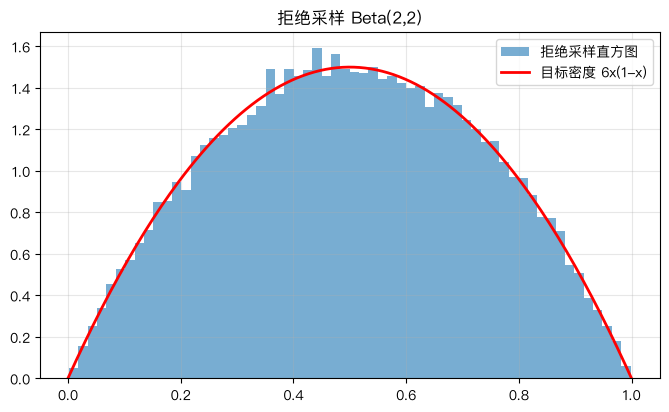

In [3]:
rng = np.random.default_rng(0)
# 目标：Beta(2,2)（密度 6x(1-x)），包装：U(0,1)，M = 1.6（≥ 最大值 1.5）
p = lambda x: 6*x*(1-x)
q = 1.0
M = 1.6

samples = []
total_draws = 0
while len(samples) < 100000:
    X = rng.random(200000)
    U = rng.random(200000)
    total_draws += 200000
    acc = p(X) / (M*q)
    samples.extend(X[U < acc])
rate = len(samples) / total_draws
samples = np.array(samples[:50000])
print(f"实际接受率 = {rate:.3f}（理论 1/M = {1/M:.3f}）")

xs = np.linspace(0, 1, 200)
plt.figure(figsize=(8, 4.5))
plt.hist(samples, bins=60, density=True, alpha=0.6, label='拒绝采样直方图')
plt.plot(xs, p(xs), 'r-', lw=2, label='目标密度 6x(1-x)')
plt.legend(); plt.grid(alpha=0.3)
plt.title('拒绝采样 Beta(2,2)')
print(f"样本均值 = {samples.mean():.4f}（解析 0.5）")


## 4. 重要性采样：换一个分布算期望


要算 $\mathbb{E}_p[g]$，可以用另一个分布 $q$ 采样并加权（权重 $= p/q$）：

$$\mathbb{E}_p[g(X)] = \int g(x)p(x)\,dx = \int g(x)\frac{p(x)}{q(x)}\,q(x)\,dx = \mathbb{E}_q\Big[g(X)\frac{p(X)}{q(X)}\Big]$$

这在深度学习里就是**重要性加权**——离线策略强化学习、off-policy 数据都靠它。


In [4]:
rng = np.random.default_rng(0)
# E_p[X]，p = Beta(2,2)，用 U(0,1) 采样
g = lambda x: x
w = lambda x: 6*x*(1-x)          # p(x)/q(x)，q(x)=1
U = rng.random(200000)
est = (g(U) * w(U)).mean()
print(f"重要性采样估计 E[X] = {est:.4f}（解析 0.5）")
print(f"未加权朴素估计   E[U] = {U.mean():.4f}（错误答案，因为没有权重）")


重要性采样估计 E[X] = 0.5005（解析 0.5）
未加权朴素估计   E[U] = 0.4993（错误答案，因为没有权重）


## 5. MCMC：马尔可夫链蒙特卡洛


高维目标分布常常连"包装分布"都找不到。MCMC 的思路：构造一条**马尔可夫链**，使其平稳分布 = 目标分布，沿着链采样即可。

Metropolis-Hastings（最简形式）：

1. 从当前 $x$ 提议 $x' = x + \text{噪声}$
2. 接受概率 $\alpha = \min\big(1, \, p(x')/p(x)\big)$
3. 接受则移动到 $x'$，否则留在 $x$

长时间后，链的访问频率 ≈ 目标密度。


接受率 = 0.707（步长 1 的随机游走，过大/过小都要调步长）


样本均值 = -0.0151，标准差 = 0.9913（解析 0, 1）


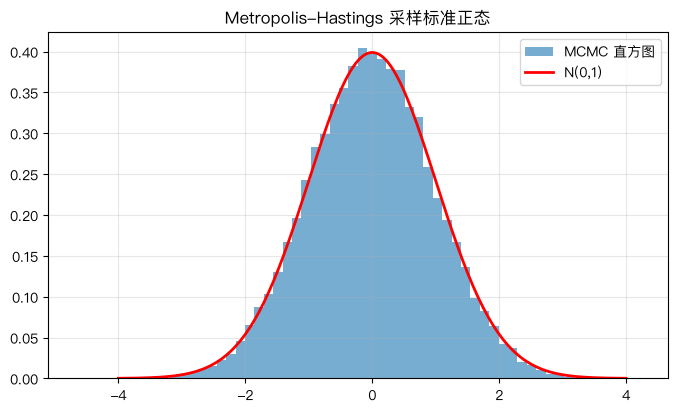

In [5]:
# 1D Metropolis：采样 N(0,1)
rng = np.random.default_rng(2)
x = 0.0
samples = []
accepted = 0
for _ in range(50000):
    xp = x + rng.standard_normal()          # 提议：随机游走
    alpha = min(1.0, np.exp(-0.5*xp**2 + 0.5*x**2))
    if rng.random() < alpha:
        x = xp
        accepted += 1
    samples.append(x)
samples = np.array(samples[5000:])          # 丢弃 burn-in
print(f"接受率 = {accepted/50000:.3f}（步长 1 的随机游走，过大/过小都要调步长）")

xs = np.linspace(-4, 4, 200)
plt.figure(figsize=(8, 4.5))
plt.hist(samples, bins=60, density=True, alpha=0.6, label='MCMC 直方图')
plt.plot(xs, np.exp(-xs**2/2)/np.sqrt(2*np.pi), 'r-', lw=2, label='N(0,1)')
plt.legend(); plt.grid(alpha=0.3)
plt.title('Metropolis-Hastings 采样标准正态')
print(f"样本均值 = {samples.mean():.4f}，标准差 = {samples.std():.4f}（解析 0, 1）")


## 6. 深度学习中的采样


- **mini-batch**：从训练集均匀采样 → 期望梯度的蒙特卡洛估计（calculus 06）
- **Dropout**：训练 = 采样"子网络"做平均集成（nn-core 04）
- **重参数化技巧**：$z = \mu + \sigma\odot\varepsilon,\ \varepsilon \sim N(0,I)$，把"从分布采样"变成"确定性函数+噪声"——让采样可求导（08 课 VAE 用）
- **语言模型生成**：从模型输出的概率分布采样下一个 token（架构模块 05 课）


## 课后练习


1. **逆变换**：$X = -\ln(1-U)/\lambda$ 已推导，试用同一方法构造 $U(a,b)$ 与柯西分布的采样器。
2. **中心极限**：数值验证蒙特卡洛误差 ∝ $1/\sqrt{n}$（不同 $n$ 下重复估计，看误差减半的规律）。
3. **拒绝采样**：把包装分布改成 $N(0, 4)$ 截断到 $[0,1]$，比较接受率与 $U(0,1)$ 方案。
4. **MCMC**：把提议步长从 1 改成 0.1 与 3，观察接受率与自相关的变化。
5. **思考**：重要性采样的权重 $p/q$ 方差很大时会发生什么？（提示：$\mathrm{Var}$ 放大，权重退化）
